In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment = pd.read_csv("C:/Users/SRIVALLI/Desktop/internshala/New folder/fear_greed_index.csv")
trades = pd.read_csv("C:/Users/SRIVALLI/Desktop/internshala/New folder/historical_data.csv")

In [4]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [5]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')

In [6]:
trades['date'] = trades['timestamp'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [7]:
merged = pd.merge(trades, sentiment, on='date')

In [8]:
print(merged.shape)
merged.head()

(184263, 20)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed


In [9]:
merged.rename(columns={'closed pnl': 'closed_pnl'}, inplace=True)
merged['closed_pnl'] = pd.to_numeric(merged['closed_pnl'], errors='coerce')

In [10]:
print(merged.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed_pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')


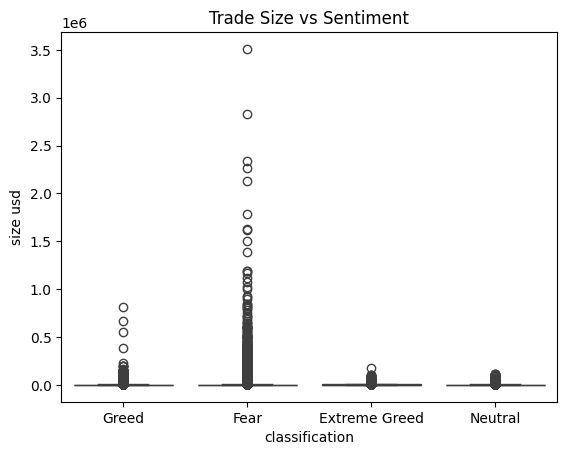

In [11]:
sns.boxplot(x='classification', y='size usd', data=merged)
plt.title("Trade Size vs Sentiment")
plt.show()

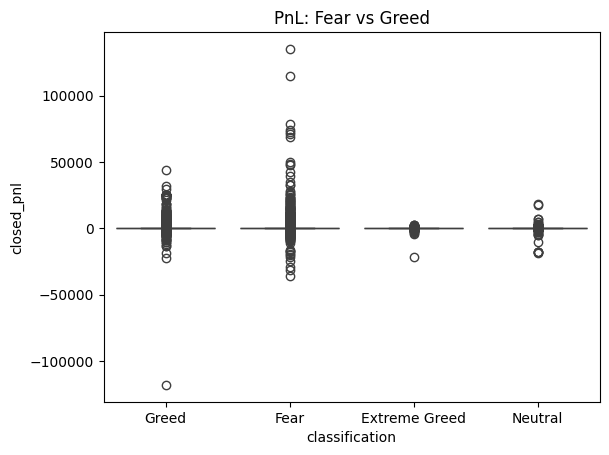

In [12]:
sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("PnL: Fear vs Greed")
plt.show()

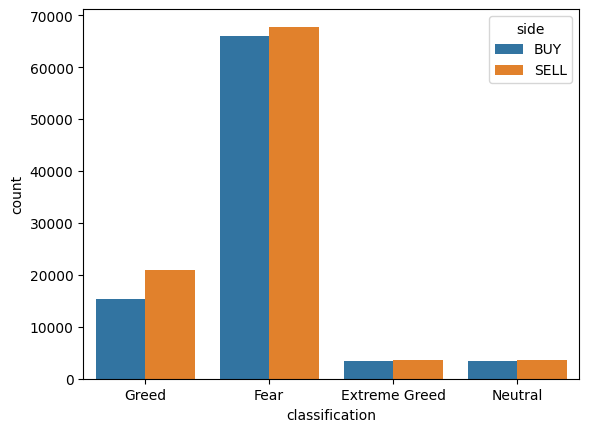

In [13]:
sns.countplot(x='classification', hue='side', data=merged)
plt.show()

## Key Insights

1. Trader performance varies across sentiment, with Greed and Neutral showing higher variability.
2. Greed periods are associated with higher risk-taking behavior.
3. Fear periods show more consistent losses and unstable performance.
4. Extreme outliers indicate potential high-risk trades leading to significant losses.

## Strategy Recommendations

1. Reduce leverage and risk exposure during Greed periods.
2. Adopt a defensive and low-frequency trading approach during Fear periods.

These insights suggest that trader behavior is strongly influenced by market sentiment, and adapting strategies accordingly can significantly improve risk management.